Step 1: Load and Inspect Truck Dataset
Load `truck.csv`, which contains list prices (`list_price` / $x$) and actual best sale prices (`best_price` / $y$) for new GMC pickup trucks in thousands of dollars.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_truck = pd.read_csv("truck.csv")

print("Columns found in truck.csv:", df_truck.columns.tolist())

if 'list_price' in df_truck.columns and 'best_price' in df_truck.columns:
    x = df_truck['list_price']
    y = df_truck['best_price']
elif 'x' in df_truck.columns and 'y' in df_truck.columns:
    x = df_truck['x']
    y = df_truck['y']
else:
    x = df_truck.iloc[:, 0]
    y = df_truck.iloc[:, 1]

print("Successfully assigned x and y variables.")
df_truck.head()

Columns found in truck.csv: ['X', 'Y']
Successfully assigned x and y variables.


,X,Y
0,12.4,11.2
1,14.3,12.5
2,14.5,12.7
3,14.9,13.1
4,16.1,14.1


Step 2 & 3: Correlation, Regression, and Prediction
Compute Pearson’s coefficient, fit the linear regression model, and predict the best price for a list price of $25.2 ($25,200).

In [2]:
r_value = np.corrcoef(x, y)[0, 1]
print(f"Pearson's r: {r_value:.4f}")

slope, intercept = np.polyfit(x, y, 1)
print(f"Regression Equation: Best Price = {slope:.4f} * x + {intercept:.4f}")

target_list_price = 25.2
predicted_best_price = slope * target_list_price + intercept
print(f"Predicted best price for list price {target_list_price}: ${predicted_best_price:.2f}k (${predicted_best_price * 1000:,.2f})")

Pearson's r: 0.9985
Regression Equation: Best Price = 0.8511 * x + 0.4346
Predicted best price for list price 25.2: $21.88k ($21,883.41)


The result is a Pearson's coefficient of 0.9985, which indicates an extremely strong positive linear correlation. This matches the Consumer's Digest data. 

Step 4: Scatter Plot and Fitted Line
Plot the scatter of list prices vs. best prices along with the regression line to visualize the near-perfect linearity.

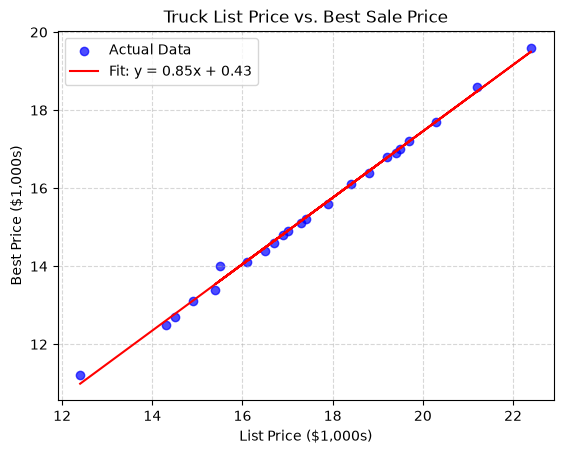

In [3]:
plt.scatter(x, y, color='blue', alpha=0.7, label='Actual Data')
plt.plot(x, slope * x + intercept, color='red', label=f'Fit: y = {slope:.2f}x + {intercept:.2f}')
plt.title("Truck List Price vs. Best Sale Price")
plt.xlabel("List Price ($1,000s)")
plt.ylabel("Best Price ($1,000s)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Step 5: Numeric Prediction
Using the regression model, predict the best sale price for a pickup truck with a list price of $25,200 ($25.2 in thousands).

In [4]:
target_list_price = 25.2

predicted_best_price = slope * target_list_price + intercept

print(f"For a list price of ${target_list_price}k, the predicted best price is ${predicted_best_price:.2f}k (${predicted_best_price * 1000:,.2f}).")

For a list price of $25.2k, the predicted best price is $21.88k ($21,883.41).


Step 6: Confidence Argument

Because the correlation coefficient is extremely high and the data points cluster tightly along the regression line, I find this prediction to be very reliable for the range of listed prices. With that being said, historical pricing does not account for current market fluctuations, regional rebates, or dealer incentives, which means we cannot have absolute confidence (but we can be quite close!). 